In [8]:
import torch
print(torch.backends.mps.is_available())  # True이면 Apple GPU 사용 가능

True


🔍 학습이 부족하여 발생할 수 있는 문제
1.	정확도(Confidence Score) 낮음
- 위 이미지에서 "straw-ripe" 클래스의 신뢰도가 0.50(50%)으로 낮게 나왔습니다.
- 모델이 충분한 데이터와 학습을 거치지 않으면 객체를 정확하게 분류하는 능력이 떨어질 수 있습니다.
2.	잘못된 분류 가능성
- 딸기가 실제로는 “unripe(덜 익음)” 상태인데 “straw-ripe”로 탐지되었다면, 데이터가 부족하거나 모델이 아직 특징을 제대로 학습하지 못한 것입니다.
- 데이터셋의 품질과 개수도 중요한 요인이 됩니다.
3.	과소적합(Underfitting) 문제
- Epoch이 너무 작으면 모델이 데이터의 패턴을 제대로 학습하지 못해 성능이 낮을 수 있습니다.
- 일반적으로 YOLO 학습에서는 50~100 epoch 이상을 추천합니다.

In [9]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

# Apple GPU(MPS)로 학습 실행
model.train(
    data="../data/dataset/data.yaml",
    epochs=10,
    imgsz=640,
    batch=16,
    device="mps"  # Mac GPU 사용
)

New https://pypi.org/project/ultralytics/8.3.78 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.76 🚀 Python-3.10.16 torch-2.6.0 MPS (Apple M4 Pro)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=../data/dataset/data.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=mps, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=F

train: Scanning /Users/songbeom/final-project/farm-web-python/src/data/dataset/train/labels.cache... 873 images, 0 backgrounds, 0 corrupt: 100%|██████████| 873/873 [00:00<?, ?it/s]
val: Scanning /Users/songbeom/final-project/farm-web-python/src/data/dataset/valid/labels.cache... 76 images, 0 backgrounds, 0 corrupt: 100%|██████████| 76/76 [00:00<?, ?it/s]

Plotting labels to /Users/songbeom/final-project/farm-web-python/runs/detect/train/labels.jpg... 


optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001667, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to /Users/songbeom/final-project/farm-web-python/runs/detect/train
Starting training for 10 epochs...
Closing dataloader mosaic

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


       1/10      4.57G     0.8356      2.022      1.149         27        640: 100%|██████████| 55/55 [00:51<00:00,  1.06it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:08<00:00,  2.74s/it]

...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):  33%|███▎      | 1/3 [00:10<00:20, 10.30s/it]

WARNING ⚠️ NMS time limit 3.600s exceeded


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:22<00:00,  7.48s/it]


                   all         76        197       0.93      0.632      0.689      0.531
            straw-ripe         76        129      0.956      0.558      0.637      0.544
          straw-unripe         24         68      0.904      0.706      0.742      0.517
Speed: 1.0ms preprocess, 29.2ms inference, 0.0ms loss, 133.6ms postprocess per image
Results saved to /Users/songbeom/final-project/farm-web-python/runs/detect/train


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x34ee71c90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [13]:
from ultralytics import YOLO

# YOLOv8n(가벼운 버전) 로드
model = YOLO("/Users/songbeom/final-project/farm-web-python/runs/detect/train/weights/best.pt")

# 모델 정보 출력
model.info()


Model summary: 129 layers, 3,011,238 parameters, 0 gradients, 8.2 GFLOPs


(129, 3011238, 0, 8.1952256)

Model summary: 129 layers, 3,011,238 parameters, 0 gradients, 8.2 GFLOPs

image 1/1 /Users/songbeom/final-project/farm-web-python/src/models/unripe_002.jpg: 640x544 1 straw-ripe, 26.4ms
Speed: 1.9ms preprocess, 26.4ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 544)


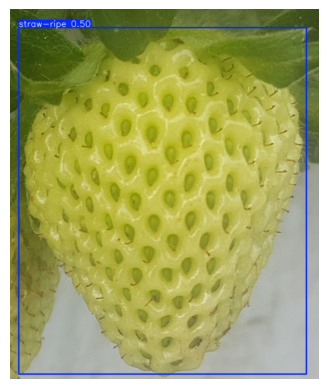

In [1]:
from ultralytics import YOLO

# YOLOv8n(가벼운 버전) 로드
model = YOLO("/Users/songbeom/final-project/farm-web-python/runs/detect/train/weights/best.pt")

# 모델 정보 출력
model.info()

import cv2
import matplotlib.pyplot as plt

# 객체 탐지 수행
results = model("unripe_002.jpg")

# 탐지된 이미지 가져오기
img = results[0].plot()  # Bounding Box 그리기

# Matplotlib으로 출력
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()